# 01. Carga y Preparación de Datos - Estrategia Momentum

Este notebook se encarga de cargar el histórico de precios desde la base de datos local (Parquet), transformar los datos al formato multi-índice requerido por la estrategia y generar el archivo base para los siguientes análisis.

Este módulo constituye el primer paso de la práctica. Su objetivo es la ingesta de datos históricos y la preparación de la base de datos maestra para la estrategia de Momentum del S&P 500.

## Objetivos según la Práctica
*   **Periodo de Análisis**: Datos desde el 1 de enero de 2015 hasta la actualidad.
*   **Universo**: Activos del S&P 500 registrados en la base de datos histórica.
*   **Benchmark**: Preparación para la descarga posterior o integración del SPY.

## Flujo de Trabajo
1.  **Ingesta de Datos**: Lectura del archivo `BDD/sp500_history.parquet`.
2.  **Cálculo de Precios Nominales**:
    *   Generación de precios **Close** nominales (sin ajustar).
    *   Generación de precios **Open** nominales para simular ejecuciones realistas.
    *   Cálculo del **Factor de Ajuste** para reconstruir la historia de precios.
3.  **Estructuración Multi-Índice**: Organización de los datos en niveles `(Atributo, Ticker)` para permitir operaciones vectorizadas eficientes en pandas.
4.  **Exportación**: Almacenamiento en `Datos/momentum_raw_data.csv`.

## Estructura del Dataset Maestros
El archivo `momentum_raw_data.csv` incluye para cada ticker:
*   `Adj Close`: Precio ajustado por dividendos y splits (base para señales).
*   `Close`: Precio nominal de cierre.
*   `Open`: Precio nominal de apertura.

## Notas de Implementación
*   Se utiliza `pyarrow` para la lectura eficiente del archivo Parquet.
*   Se asegura que el directorio `Datos/` esté disponible para la persistencia del proyecto.


In [1]:
import pandas as pd
import os

parquet_path = 'BDD/sp500_history.parquet'
output_path = 'Datos/momentum_raw_data.csv'

if not os.path.exists(parquet_path):
    raise FileNotFoundError(f"No se encontró el archivo {parquet_path}")

print(f"🚀 Cargando datos desde {parquet_path}...")
# Usamos pyarrow para mayor velocidad y compatibilidad
df_orig = pd.read_parquet(parquet_path, engine='pyarrow')
# Asegurar formato de fecha
df_orig['date'] = pd.to_datetime(df_orig['date'])

🚀 Cargando datos desde BDD/sp500_history.parquet...


In [2]:
# Asegurar que in_sp500 no tenga NaNs (tratarlos como 0)
df_orig['in_sp500'] = df_orig['in_sp500'].fillna(0)
# Filtramos y sobreescribimos el original
df_orig = df_orig[df_orig['in_sp500'] != 0]

In [3]:
# 2. Filtramos duplicados y ordenamos por nombre
lista_tickers = df_orig.drop_duplicates(subset=['symbol', 'security_name']).sort_values('security_name')

# 3. Imprimimos TODO el contenido sin índices y sin recortes
# Seleccionamos las columnas en el orden deseado antes de imprimir
print(lista_tickers[['security_name', 'symbol']].to_string(index=False))

# Opcional: imprimir el conteo al final para verificar
print(f"\n✅ Total de registros: {len(lista_tickers)}")

                                             security_name       symbol
                                   3Com Corporation Common  COMS-201004
                                              3M Co Common          MMM
                                   A. O. Smith Corp Common          AOS
                                        ABIOMED Inc Common  ABMD-202212
                         ADC Telecommunications Inc Common  ADCT-201012
                                           ADT Corp Common   ADT-201604
                                           AES Corp Common          AES
                                  AGL Resources Inc Common   GAS-201606
                              AK Steel Holding Corp Common   AKS-202003
                                         AMETEK Inc Common          AME
                                            AMP Inc Common   AMP-199904
                                           AMR Corp Common AAMRQ-201312
                                          ANSYS Inc Common  ANSS

In [4]:
# Aplicar la normalización
df_orig['company_group'] = df_orig['security_name'].str.split(' Class').str[0].str.strip()

replacements = {
    r'\bCorporation\b': 'Corp',
    r'\bIncorporated\b': 'Inc',
    r'[\.,]': '',  # Elimina puntos y comas
    r'\s+': ' '   # Colapsa espacios múltiples
}

for pattern, replacement in replacements.items():
    df_orig['company_group'] = df_orig['company_group'].str.replace(pattern, replacement, regex=True, case=False)

df_orig['company_group'] = df_orig['company_group'].str.upper()

In [5]:
# Primero eliminamos duplicados exactos (mismo grupo y mismo ticker)
df_unique = df_orig[['company_group', 'symbol']].drop_duplicates()

# Agrupamos por 'company_group' y transformamos los símbolos en una lista o cadena
grouped = df_unique.groupby('company_group')['symbol'].apply(lambda x: ', '.join(x)).reset_index()

# 4. Filtrar: Contar cuántos tickers hay en la cadena (contando las comas + 1)
# O más fácil, filtrar por aquellos que originalmente tenían más de un registro
counts = df_unique.groupby('company_group')['symbol'].count()
multi_ticker_groups = counts[counts > 1].index

resultado_final = grouped[grouped['company_group'].isin(multi_ticker_groups)]

# 5. Imprimir con formato limpio
print(f"{'COMPANY_GROUP':<40} {'TICKERS RELACIONADOS'}")
print("-" * 70)
print(resultado_final.to_string(index=False, header=False))

print(f"\n✅ Total de grupos con múltiples tickers: {len(resultado_final)}")

COMPANY_GROUP                            TICKERS RELACIONADOS
----------------------------------------------------------------------
                  ALPHABET INC               GOOG, GOOGL
                  COMCAST CORP       CMCSA, CMCSK-201512
    DOLLAR GENERAL CORP COMMON             DG-200707, DG
                      FOX CORP                 FOX, FOXA
GENERAL INSTRUMENT CORP COMMON    GIC-200001, GRL-199008
         MANOR CARE INC COMMON    HCR-200712, MNR-199809
          MCKESSON CORP COMMON           MCK-199411, MCK
                     NEWS CORP                 NWS, NWSA
           PROLOGIS INC COMMON           PLD-201106, PLD
      SAFETY KLEEN CORP COMMON      SK-199805, SK-200006
           SANDISK CORP COMMON         SNDK-201605, SNDK
        TIME WARNER INC COMMON    TWX-200101, TWX-201806
  TWENTY-FIRST CENTURY FOX INC TFCF-201903, TFCFA-201903
              UNDER ARMOUR INC                   UA, UAA
             US BANCORP COMMON           USB-200102, USB
          WA

In [6]:
# --- FILTRADO POR COINCIDENCIA EN FECHA ---

# 1. Identificar qué grupos tienen más de un ticker en la misma fecha
# Agrupamos por fecha y grupo, y contamos cuántos tickers únicos hay ese día
coincidencias_por_fecha = df_orig.groupby(['date', 'company_group'])['symbol'].nunique()

# 2. Obtenemos los nombres de los grupos que alguna vez tuvieron > 1 ticker el mismo día
grupos_con_solape = coincidencias_por_fecha[coincidencias_por_fecha > 1].index.get_level_values('company_group').unique()

# 3. Filtramos nuestro resultado_final anterior para que solo contenga estos grupos
resultado_coincidentes = resultado_final[resultado_final['company_group'].isin(grupos_con_solape)]

# 4. Imprimir el nuevo listado filtrado
print(f"\n--- GRUPOS CUYOS TICKERS COINCIDEN EN EL TIEMPO ---")
print(f"{'COMPANY_GROUP':<40} {'TICKERS COEXISTENTES'}")
print("-" * 70)

if resultado_coincidentes.empty:
    print("No se encontraron tickers que coincidan en las mismas fechas.")
else:
    print(resultado_coincidentes.to_string(index=False, header=False))

print(f"\n✅ Total de grupos con coexistencia temporal: {len(resultado_coincidentes)}")


--- GRUPOS CUYOS TICKERS COINCIDEN EN EL TIEMPO ---
COMPANY_GROUP                            TICKERS COEXISTENTES
----------------------------------------------------------------------
                ALPHABET INC               GOOG, GOOGL
                COMCAST CORP       CMCSA, CMCSK-201512
                    FOX CORP                 FOX, FOXA
                   NEWS CORP                 NWS, NWSA
    SAFETY KLEEN CORP COMMON      SK-199805, SK-200006
      TIME WARNER INC COMMON    TWX-200101, TWX-201806
TWENTY-FIRST CENTURY FOX INC TFCF-201903, TFCFA-201903
            UNDER ARMOUR INC                   UA, UAA
           US BANCORP COMMON           USB-200102, USB
        WACHOVIA CORP COMMON      WB-200108, WB-200812
     WELLS FARGO & CO COMMON           WFC-199811, WFC

✅ Total de grupos con coexistencia temporal: 11


Caso especial:
Lo que sucede con Allergan es un caso clásico de "superposición de linajes" en bases de datos financieras. AGN-201503 (Allergan Inc.) fue adquirida por Actavis, pero la nueva entidad decidió mantener el nombre Allergan (pasando a ser AGN-202005 Allergan PLC).

In [7]:
print(df_orig.loc[df_orig['symbol'].str.contains('AGN-201503', regex=True),['date' ,'symbol','company_group','close','in_sp500']].head(1))
print(df_orig.loc[df_orig['symbol']=='AGN-202005',['date' ,'symbol','company_group','close','in_sp500']].head(1))
print(df_orig.loc[df_orig['symbol'].str.contains('AGN-201503', regex=True),['date' ,'symbol','company_group','close','in_sp500']].tail(1))
print(df_orig.loc[df_orig['symbol']=='AGN-202005',['date' ,'symbol','company_group','close','in_sp500']].tail(1))

             date      symbol        company_group     close  in_sp500
210354 1992-02-10  AGN-201503  ALLERGAN INC COMMON  5.321399         1
             date      symbol        company_group      close  in_sp500
217724 1999-04-12  AGN-202005  ALLERGAN PLC COMMON  43.446388         1
             date      symbol        company_group       close  in_sp500
216171 2015-03-16  AGN-201503  ALLERGAN INC COMMON  240.220001         1
             date      symbol        company_group       close  in_sp500
223028 2020-05-08  AGN-202005  ALLERGAN PLC COMMON  193.020004         1


In [8]:
import pandas as pd

# 1. Creamos dos subconjuntos con los tickers en cuestión
agn_inc = df_orig[df_orig['symbol'] == 'AGN-201503']
agn_plc = df_orig[df_orig['symbol'] == 'AGN-202005']

# 2. Hacemos un merge por fecha para ver dónde coinciden
# Usamos inner join para que solo nos dé las fechas que están en AMBOS registros
duplicates_check = pd.merge(
    agn_inc[['date', 'symbol', 'close', 'in_sp500']], 
    agn_plc[['date', 'symbol', 'close', 'in_sp500']], 
    on='date', 
    suffixes=('_INC', '_PLC')
)

# 3. Mostramos los resultados donde hay solapamiento
if not duplicates_check.empty:
    print(f"Se han encontrado {len(duplicates_check)} días de duplicidad.")
    print("-" * 50)
    # Mostramos las primeras y últimas filas del solape para ver el rango temporal
    print(duplicates_check.head(5))
    # print("...")
    # print(duplicates_check.tail(5))
else:
    print("No se encontró un solapamiento exacto de fechas entre estos dos registros.")

Se han encontrado 4008 días de duplicidad.
--------------------------------------------------
        date  symbol_INC  close_INC  in_sp500_INC  symbol_PLC  close_PLC  \
0 1999-04-12  AGN-201503  20.866285             1  AGN-202005  43.446388   
1 1999-04-13  AGN-201503  21.562302             1  AGN-202005  43.977661   
2 1999-04-14  AGN-201503  20.397539             1  AGN-202005  42.442871   
3 1999-04-15  AGN-201503  19.800955             1  AGN-202005  39.432320   
4 1999-04-16  AGN-201503  19.261187             1  AGN-202005  41.557415   

   in_sp500_PLC  
0             1  
1             1  
2             1  
3             1  
4             1  


In [9]:
# --- MÉTRICAS DE TICKERS COEXISTENTES (FECHAS Y PRECIOS) ---

# 1. Filtramos el dataframe original para quedarnos solo con los grupos que tienen solape
df_solapados = df_orig[df_orig['company_group'].isin(grupos_con_solape)]

# 2. Calculamos métricas por ticker: total de fechas y última cotización
# Nota: Si tu columna de precio no es 'close', cámbiala aquí (ej. 'adj_close')
metricas_tickers = (df_solapados.sort_values('date')
                    .groupby(['company_group', 'symbol'])
                    .agg(total_fechas=('date', 'count'),
                         ultimo_precio=('close', 'last'))
                    .reset_index())

# 3. Identificamos cuál es el más caro dentro de cada grupo
metricas_tickers['max_precio_grupo'] = metricas_tickers.groupby('company_group')['ultimo_precio'].transform('max')
metricas_tickers['es_mas_caro'] = metricas_tickers['ultimo_precio'] == metricas_tickers['max_precio_grupo']

# 4. Formatear e Imprimir los resultados de forma legible
print(f"\n{'EMPRESA / TICKER':<45} {'FECHAS':<10} {'ÚLT. PRECIO':<15} {'NOTA'}")
print("-" * 85)

for grupo in grupos_con_solape:
    sub = metricas_tickers[metricas_tickers['company_group'] == grupo]
    for _, row in sub.iterrows():
        nota = "[MÁS CARO]" if row['es_mas_caro'] else ""
        # Imprimimos la fila con formato alineado
        print(f"{row['company_group'][:25]:<25} | {row['symbol']:<15} {row['total_fechas']:<10} ${row['ultimo_precio']:>10.2f}   {nota}")


EMPRESA / TICKER                              FECHAS     ÚLT. PRECIO     NOTA
-------------------------------------------------------------------------------------
SAFETY KLEEN CORP COMMON  | SK-199805       2085       $     28.31   [MÁS CARO]
SAFETY KLEEN CORP COMMON  | SK-200006       1328       $     16.50   
WELLS FARGO & CO COMMON   | WFC             9087       $     90.49   
WELLS FARGO & CO COMMON   | WFC-199811      2235       $    373.94   [MÁS CARO]
WACHOVIA CORP COMMON      | WB-200108       2000       $     69.65   [MÁS CARO]
WACHOVIA CORP COMMON      | WB-200812       4791       $      5.54   
TIME WARNER INC COMMON    | TWX-200101      2788       $     71.19   
TIME WARNER INC COMMON    | TWX-201806      4894       $     98.77   [MÁS CARO]
US BANCORP COMMON         | USB             6811       $     56.11   [MÁS CARO]
US BANCORP COMMON         | USB-200102      1348       $     28.48   
ALPHABET INC              | GOOG            2975       $    338.53   [MÁS CARO]
ALPHA

In [10]:
# --- ELIMINACIÓN POR HISTORIAL Y PRECIO (DESEMPATE) ---

# 1. Ordenamos el resumen de métricas: 
# Primero por grupo, luego por fechas (descendente) y luego por precio (descendente)
metricas_ordenadas = metricas_tickers.sort_values(
    by=['company_group', 'total_fechas', 'ultimo_precio'], 
    ascending=[True, False, False]
)

# 2. Seleccionamos el "ganador" de cada grupo (la primera fila de cada grupo tras el sort)
tickers_a_mantener = metricas_ordenadas.groupby('company_group').head(1)['symbol'].unique()

# 3. Los tickers a eliminar son todos aquellos que están en grupos con solape pero NO son los ganadores
tickers_en_solape = metricas_tickers['symbol'].unique()
tickers_a_eliminar = [t for t in tickers_en_solape if t not in tickers_a_mantener]

# 4. Procedemos a eliminar del DataFrame original
df_limpio = df_orig[~df_orig['symbol'].isin(tickers_a_eliminar)].copy()
df = None
# 5. Reporte detallado de la "limpieza"
print(f"--- RESUMEN DE LIMPIEZA (CRITERIO: HISTORIAL > PRECIO) ---")
if len(tickers_a_eliminar) > 0:
    # Mostramos qué se eliminó y por qué
    eliminados_info = metricas_tickers[metricas_tickers['symbol'].isin(tickers_a_eliminar)]
    for _, row in eliminados_info.iterrows():
        print(f"❌ Eliminado: {row['symbol']:<7} | Historial: {row['total_fechas']:<5} | Precio: ${row['ultimo_precio']:>8.2f} | Grupo: {row['company_group']}")
    
    print(f"\n✅ Se han eliminado {len(tickers_a_eliminar)} tickers.")
    print(f"📊 Registros eliminados del DataFrame: {len(df_orig) - len(df_limpio):,}")
    
    # Actualizamos el DataFrame original
    df = df_limpio
else:
    print("No se encontraron tickers para eliminar bajo estos criterios.")

print(f"📉 Tamaño final del DataFrame: {len(df_orig):,} filas")

--- RESUMEN DE LIMPIEZA (CRITERIO: HISTORIAL > PRECIO) ---
❌ Eliminado: GOOG    | Historial: 2975  | Precio: $  338.53 | Grupo: ALPHABET INC
❌ Eliminado: CMCSK-201512 | Historial: 59    | Precio: $   58.00 | Grupo: COMCAST CORP
❌ Eliminado: FOX     | Historial: 1728  | Precio: $   65.57 | Grupo: FOX CORP
❌ Eliminado: NWS     | Historial: 2606  | Precio: $   31.10 | Grupo: NEWS CORP
❌ Eliminado: SK-200006 | Historial: 1328  | Precio: $   16.50 | Grupo: SAFETY KLEEN CORP COMMON
❌ Eliminado: TWX-200101 | Historial: 2788  | Precio: $   71.19 | Grupo: TIME WARNER INC COMMON
❌ Eliminado: TFCF-201903 | Historial: 879   | Precio: $   49.61 | Grupo: TWENTY-FIRST CENTURY FOX INC
❌ Eliminado: UA      | Historial: 1561  | Precio: $    8.38 | Grupo: UNDER ARMOUR INC
❌ Eliminado: USB-200102 | Historial: 1348  | Precio: $   28.48 | Grupo: US BANCORP COMMON
❌ Eliminado: WB-200108 | Historial: 2000  | Precio: $   69.65 | Grupo: WACHOVIA CORP COMMON
❌ Eliminado: WFC-199811 | Historial: 2235  | Precio: $

In [11]:
# --- FILTRADO POR COINCIDENCIA EN FECHA ---

# 1. Identificar qué grupos tienen más de un ticker en la misma fecha
# Agrupamos por fecha y grupo, y contamos cuántos tickers únicos hay ese día
coincidencias_por_fecha = df.groupby(['date', 'company_group'])['symbol'].nunique()

# 2. Obtenemos los nombres de los grupos que alguna vez tuvieron > 1 ticker el mismo día
grupos_con_solape = coincidencias_por_fecha[coincidencias_por_fecha > 1].index.get_level_values('company_group').unique()

# 3. Filtramos nuestro resultado_final anterior para que solo contenga estos grupos
resultado_coincidentes = resultado_final[resultado_final['company_group'].isin(grupos_con_solape)]

# 4. Imprimir el nuevo listado filtrado
print(f"\n--- GRUPOS CUYOS TICKERS COINCIDEN EN EL TIEMPO ---")
print(f"{'COMPANY_GROUP':<40} {'TICKERS COEXISTENTES'}")
print("-" * 70)

if resultado_coincidentes.empty:
    print("No se encontraron tickers que coincidan en las mismas fechas.")
else:
    print(resultado_coincidentes.to_string(index=False, header=False))

print(f"\n✅ Total de grupos con coexistencia temporal: {len(resultado_coincidentes)}")


--- GRUPOS CUYOS TICKERS COINCIDEN EN EL TIEMPO ---
COMPANY_GROUP                            TICKERS COEXISTENTES
----------------------------------------------------------------------
No se encontraron tickers que coincidan en las mismas fechas.

✅ Total de grupos con coexistencia temporal: 0


In [12]:
# 4. Crear el mapeo final (Ticker -> Nombre Normalizado)
# Nos quedamos solo con los tickers que están en nuestra lista final
mapping = (df.groupby('symbol')['company_group']
           .first() # Tomamos el primer nombre encontrado para ese ticker
           .reset_index())

mapping.columns = ['Ticker', 'Nombre_Normalizado']
mapping = mapping.sort_values('Ticker')

# 5. Guardar y mostrar
mapping.to_csv('Datos/lista_final_nombres.csv', index=False)
print(f"✅ Lista extraída con {len(mapping)} nombres únicos.")
mapping

✅ Lista extraída con 1278 nombres únicos.


,Ticker,Nombre_Normalizado
0,A,AGILENT TECHNOLOGIES INC COMMON
1,AABA-201910,ALTABA INC COMMON
2,AAL,AMERICAN AIRLINES GROUP INC COMMON
3,AAL-199702,ALEXANDER & ALEXANDER SERVICES INC COMMON
4,AAMRQ-201312,AMR CORP COMMON
...,...,...
1273,ZBRA,ZEBRA TECHNOLOGIES CORP
1274,ZE-199805,ZENITH ELECTRONICS CORP COMMON
1275,ZION,ZIONS BANCORPORATION NA COMMON
1276,ZRN-199806,ZURN INDUSTRIES INC COMMON


In [13]:
# list(df['symbol'].unique())
df.loc[df['date']=='2026-01-26','symbol'].dropna().unique().tolist()

['A',
 'AAPL',
 'ABBV',
 'ABNB',
 'ABT',
 'ACGL',
 'ACN',
 'ADBE',
 'ADI',
 'ADM',
 'ADP',
 'ADSK',
 'AEE',
 'AEP',
 'AES',
 'AFL',
 'AIG',
 'AIZ',
 'AJG',
 'AKAM',
 'ALB',
 'ALGN',
 'ALL',
 'ALLE',
 'AMAT',
 'AMCR',
 'AMD',
 'AME',
 'AMGN',
 'AMP',
 'AMT',
 'AMZN',
 'ANET',
 'AON',
 'AOS',
 'APA',
 'APD',
 'APH',
 'APO',
 'APP',
 'APTV',
 'ARE',
 'ARES',
 'ATO',
 'AVB',
 'AVGO',
 'AVY',
 'AWK',
 'AXON',
 'AXP',
 'AZO',
 'BA',
 'BAC',
 'BALL',
 'BAX',
 'BBY',
 'BDX',
 'BEN',
 'BF.B',
 'BG',
 'BIIB',
 'BK',
 'BKNG',
 'BKR',
 'BLDR',
 'BLK',
 'BMY',
 'BR',
 'BRK.B',
 'BRO',
 'BSX',
 'BX',
 'BXP',
 'C',
 'CAG',
 'CAH',
 'CARR',
 'CAT',
 'CB',
 'CBOE',
 'CBRE',
 'CCI',
 'CCL',
 'CDNS',
 'CDW',
 'CEG',
 'CF',
 'CFG',
 'CHD',
 'CHRW',
 'CHTR',
 'CI',
 'CINF',
 'CL',
 'CLX',
 'CMCSA',
 'CME',
 'CMG',
 'CMI',
 'CMS',
 'CNC',
 'CNP',
 'COF',
 'COIN',
 'COO',
 'COP',
 'COR',
 'COST',
 'CPAY',
 'CPB',
 'CPRT',
 'CPT',
 'CRH',
 'CRL',
 'CRM',
 'CRWD',
 'CSCO',
 'CSGP',
 'CSX',
 'CTAS',
 'CTRA',
 '

### Procedemos a mejorar el formato de los datos

In [14]:
print("📊 Calculando factor de corrección y pivotando datos...")
# Factor = Unadjusted / Adjusted
# Evitamos división por cero
df['factor'] = df['unadjusted_close'] / df['close'].replace(0, float('nan'))
# Pivotamos las métricas necesarias
# En este dataset:
# 'close' es el precio ajustado
# 'unadjusted_close' es el precio nominal (necesario para ventas reales)
print("⌛ Pivotando tablas (esto puede tardar unos segundos)... ")
in_sp500_pivot = df.pivot(index='date', columns='symbol', values='in_sp500')
adj_close_pivot = df.pivot(index='date', columns='symbol', values='close')
close_pivot = df.pivot(index='date', columns='symbol', values='unadjusted_close')
factor_pivot = df.pivot(index='date', columns='symbol', values='factor')
open_pivot = df.pivot(index='date', columns='symbol', values='open') * factor_pivot

print("🏗️ Construyendo DataFrame MultiÍndice...")
# Estructura: (Atributo, Ticker)
raw_data = pd.concat([adj_close_pivot, close_pivot, open_pivot, in_sp500_pivot], 
                        axis=1, 
                        keys=['Adj Close', 'Close', 'Open', 'In SP500'])

raw_data.sort_index(inplace=True)

# Garantizar existencia de carpeta
os.makedirs('Datos', exist_ok=True)

print(f"💾 Guardando en {output_path}... ")
raw_data.to_csv(output_path)

print(f"✅ Éxito: {len(raw_data)} filas, {adj_close_pivot.shape[1]} activos procesados.")

📊 Calculando factor de corrección y pivotando datos...
⌛ Pivotando tablas (esto puede tardar unos segundos)... 
🏗️ Construyendo DataFrame MultiÍndice...
💾 Guardando en Datos/momentum_raw_data.csv... 
✅ Éxito: 9087 filas, 1278 activos procesados.


### Visualización de Muestra
Verificamos que la estructura multi-índice se haya creado correctamente.

In [15]:
raw_data.head()

Adj Close                                                        \
symbol             A AABA-201910 AAL AAL-199702 AAMRQ-201312 AAP      AAPL   
date                                                                         
1990-01-02       NaN         NaN NaN  25.682434    12.648131 NaN  0.260942   
1990-01-03       NaN         NaN NaN  24.765203    12.595211 NaN  0.262693   
1990-01-04       NaN         NaN NaN  24.663290    12.436447 NaN  0.263569   
1990-01-05       NaN         NaN NaN  24.357546    12.621671 NaN  0.264444   
1990-01-08       NaN         NaN NaN  24.663290    12.515829 NaN  0.266195   

                                       ... In SP500                           \
symbol     AAV-199901 ABBV ABI-200811  ...      XYZ YELLQ YNR-200010 YUM ZBH   
date                                   ...                                     
1990-01-02  13.964755  NaN   4.236457  ...      NaN   1.0        NaN NaN NaN   
1990-01-03  14.205526  NaN   4.213923  ...      NaN   1.0        NaN NaN NaN   
1990-01-04  14.085141  NaN   4.416731  ...      NaN   1.0        NaN NaN NaN   
1990-01-05  14.446299  NaN   4.394197  ...      NaN   1.0        NaN NaN NaN   
1990-01-08  14.566684  NaN   4.416731  ...      NaN   1.0        NaN NaN NaN   

                                               
symbol     ZBRA ZE-199805 ZION ZRN-199806 ZTS  
date                                           
1990-01-02  NaN       1.0  NaN        1.0 NaN  
1990-01-03  NaN       1.0  NaN        1.0 NaN  
1990-01-04  NaN       1.0  NaN        1.0 NaN  
1990-01-05  NaN       1.0  NaN        1.0 NaN  
1990-01-08  NaN       1.0  NaN        1.0 NaN  

[5 rows x 5112 columns]

### Verificación de Acceso y Factor de Corrección

A continuación, validamos que la estructura multi-índice es correcta y comprobamos que el **Factor** guardado coincide efectivamente con la relación entre los precios nominales (`Close`) y los ajustados (`Adj Close`).

In [16]:
# 1. Listar los niveles superiores del MultiÍndice (Atributos)
print("📌 Atributos disponibles:", raw_data.columns.get_level_values(0).unique().tolist())

# 2. Ticker de ejemplo para la prueba
ticker_test = 'AAL-199702'

    
# Supongamos que tu DataFrame se llama 'df'
idx = pd.IndexSlice

raw_data.loc[:, idx[:, ticker_test]]

📌 Atributos disponibles: ['Adj Close', 'Close', 'Open', 'In SP500']


,Adj Close,Close,Open,In SP500
symbol,AAL-199702,AAL-199702,AAL-199702,AAL-199702
date,,,,
1990-01-02,25.682434,31.500,30.374998,1.0
1990-01-03,24.765203,30.375,31.500002,1.0
1990-01-04,24.663290,30.250,30.250000,1.0
1990-01-05,24.357546,29.875,30.000002,1.0
1990-01-08,24.663290,30.250,29.750000,1.0
...,...,...,...,...
2026-01-26,NaN,NaN,NaN,NaN
2026-01-27,NaN,NaN,NaN,NaN


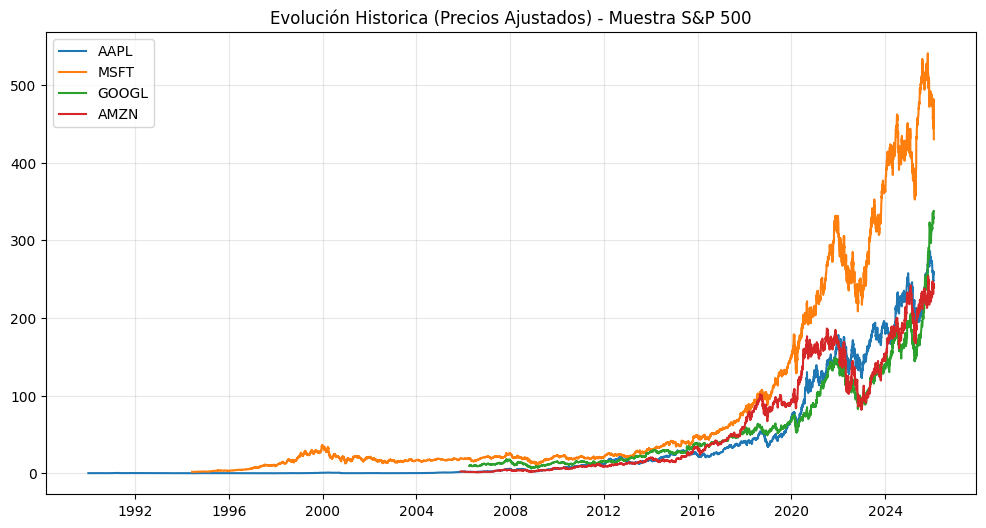

In [17]:
import matplotlib.pyplot as plt

# Seleccionamos algunos tickers conocidos para inspección visual
sample_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
available_samples = [t for t in sample_tickers if t in raw_data['Adj Close'].columns]

if available_samples:
    plt.figure(figsize=(12, 6))
    for ticker in available_samples:
        plt.plot(raw_data['Adj Close'][ticker], label=ticker)
    
    plt.title("Evolución Historica (Precios Ajustados) - Muestra S&P 500")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No se encontraron los activos de muestra especificados.")